### Import Libraries:

In [2]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Better visualization style
sns.set(style="whitegrid")

### Load Dataset:

In [3]:
# Load dataset with encoding fix
df = pd.read_csv('../data/netflix.csv', encoding='latin1')  #to fix file error

# Preview data
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Basic Info:

In [4]:
# Shape of dataset
df.shape

# Column names
df.columns

# Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8809 entries, 0 to 8808
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8809 non-null   str    
 1   type          8809 non-null   str    
 2   title         8809 non-null   str    
 3   director      6175 non-null   str    
 4   cast          7984 non-null   str    
 5   country       7978 non-null   str    
 6   date_added    8799 non-null   str    
 7   release_year  8809 non-null   int64  
 8   rating        8805 non-null   str    
 9   duration      8806 non-null   str    
 10  listed_in     8809 non-null   str    
 11  description   8809 non-null   str    
 12  Unnamed: 12   0 non-null      float64
 13  Unnamed: 13   0 non-null      float64
 14  Unnamed: 14   0 non-null      float64
 15  Unnamed: 15   0 non-null      float64
 16  Unnamed: 16   0 non-null      float64
 17  Unnamed: 17   0 non-null      float64
 18  Unnamed: 18   0 non-null      float64
 

### Missing Values:

In [5]:
# Check missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
Unnamed: 12     8809
Unnamed: 13     8809
Unnamed: 14     8809
Unnamed: 15     8809
Unnamed: 16     8809
Unnamed: 17     8809
Unnamed: 18     8809
Unnamed: 19     8809
Unnamed: 20     8809
Unnamed: 21     8809
Unnamed: 22     8809
Unnamed: 23     8809
Unnamed: 24     8809
Unnamed: 25     8809
dtype: int64

### Data Cleaning:

In [6]:
# Remove unwanted 'Unnamed' columns
df = df.drop(columns=[col for col in df.columns if 'Unnamed' in col])

# Fill missing values 
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df['rating'] = df['rating'].fillna('Not Rated')
df['duration'] = df['duration'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Not Available')

# Remove duplicates
df = df.drop_duplicates()

# Check again
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

### Plots:

1. Movies vs TV Shows

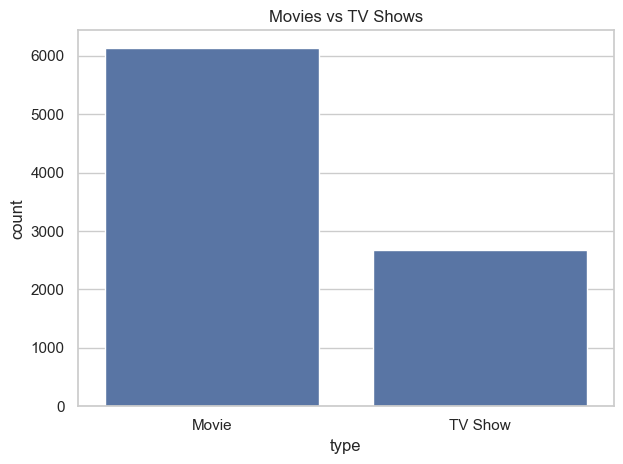

In [ ]:
plt.figure() # create new blank canvas

sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows")
plt.tight_layout()                  ## this adjust the layout of your graph

plt.savefig('../outputs/movies_vs_tvshows.png')
plt.show()

2. Content Growth Over Time

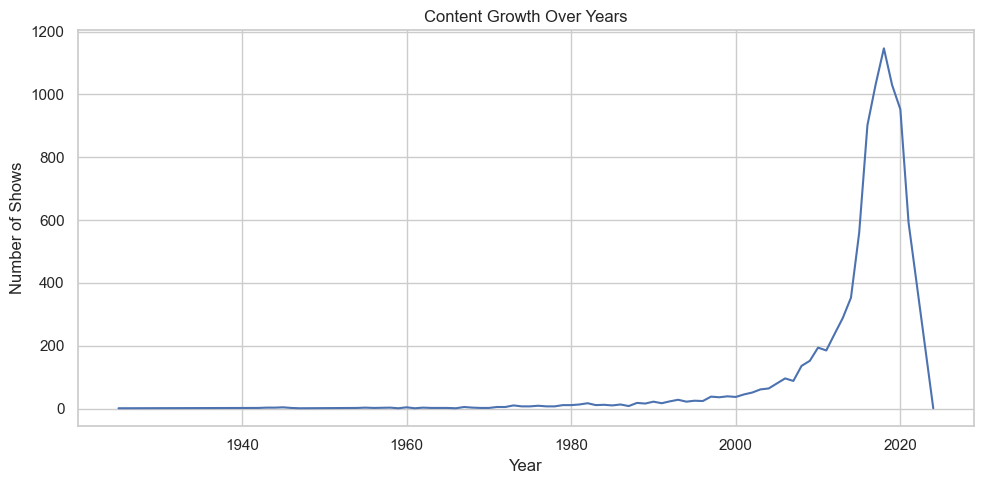

In [15]:
plt.figure(figsize=(10,5))

df['release_year'].value_counts().sort_index().plot()  #value count is in desenting so .sort_index() to ascending 

plt.title("Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Shows")
plt.tight_layout()

plt.savefig('../outputs/content_growth_overtime.png')
plt.show()

Insight:
Netflix recent years mein fast grow hua

3. Top Countries

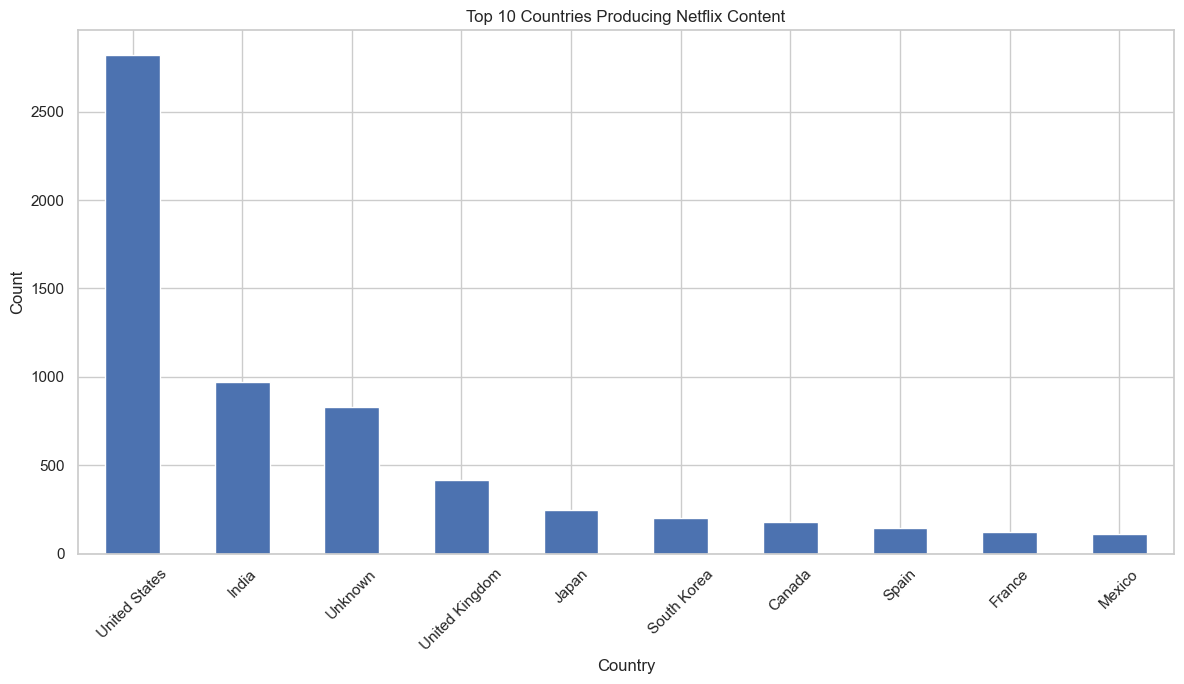

In [12]:
plt.figure(figsize=(12,7))

df['country'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('../outputs/top_10countries.png')
plt.show()

4. Top Genres

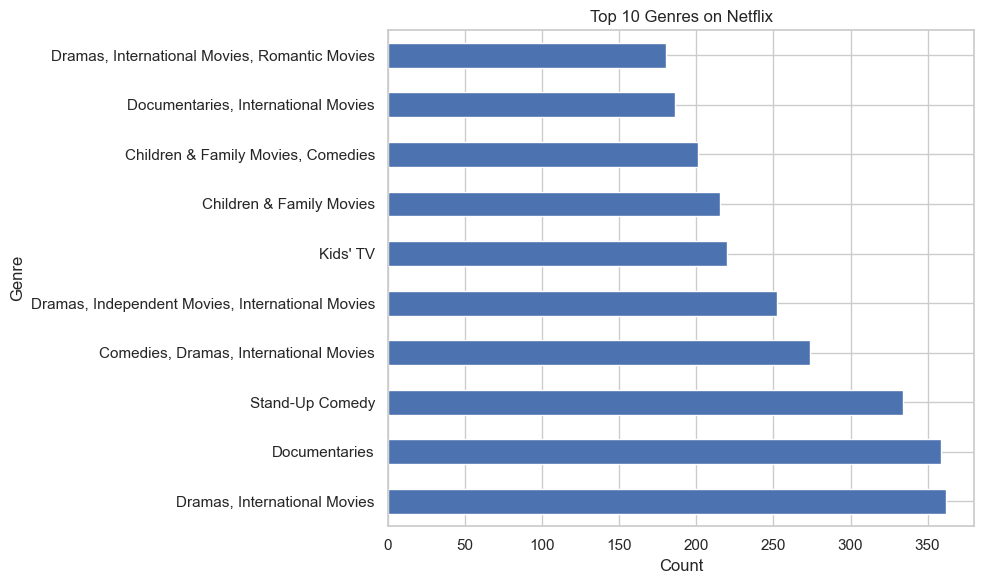

In [13]:
plt.figure(figsize=(10,6))

df['listed_in'].value_counts().head(10).plot(kind='barh')  #barh = horizontal bar chart

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()

plt.savefig('../outputs/top_genres.png')
plt.show()

4. Ratings

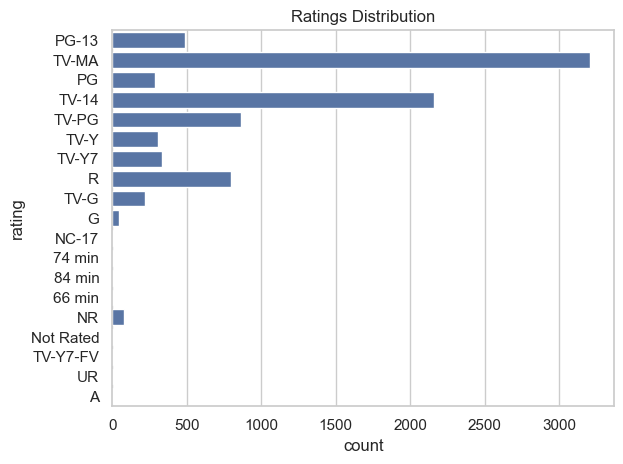

In [14]:
plt.figure()

sns.countplot(y='rating', data=df)

plt.title("Ratings Distribution")
plt.tight_layout()

plt.savefig('../outputs/ratings.png')
plt.show()